In [1]:
import torch
import torch.nn as nn
import gymnasium as gym
import numpy

from myrl.algorithms.a2c.model import AdvantageActorCriticPolicyGAE
from myrl.algorithms.a2c.train import train_loop
from myrl.optimizers.gradient_descent import PolicyGradientOptimizer

In [3]:
env = gym.make("LunarLander-v3")
model = AdvantageActorCriticPolicyGAE(
    obs_dim=env.observation_space.shape[0],
    actions_dim=env.action_space.n,
    n_hidden=2,
    hidden_dim=32,
    gamma=0.95,
    lambd=0.99,
)

# optimizer = PolicyGradientOptimizer(
#     parameters=model.parameters(),
#     alpha=1e-2
# )
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=0.01, 
    weight_decay=0.01
)

In [4]:
losses_actor, losses_value, rewards = train_loop(model, env, optimizer, n_episodes=10, n_epochs=10_000)

Epoch (0/10000): Reward = -2747.778706530314, Loss Actor = -44.51982879638672, Loss Value = 2643.374755859375
Epoch (1000/10000): Reward = -2110.8897830491105, Loss Actor = 0.3452889919281006, Loss Value = 256.9273376464844
Epoch (2000/10000): Reward = -680.6912000915553, Loss Actor = -0.022671356797218323, Loss Value = 6.158690452575684
Epoch (3000/10000): Reward = -2389.7933946976996, Loss Actor = -0.11196586489677429, Loss Value = 42.77471160888672
Epoch (4000/10000): Reward = -979.2727312026744, Loss Actor = -0.05615807697176933, Loss Value = 18.580142974853516


KeyboardInterrupt: 

In [ ]:
1+1

In [ ]:
import matplotlib.pyplot as plt

plt.plot(rewards)

In [15]:
losses_actor, losses_value, rewards = train_loop(model, env, optimizer, n_episodes=10, n_epochs=1_000)

Epoch (0/1000): Reward = -1769.0613965770012, Loss Actor = -46.835872650146484, Loss Value = 2632.92822265625
Epoch (100/1000): Reward = -1556.557159538974, Loss Actor = -5.309576034545898, Loss Value = 584.6729736328125
Epoch (200/1000): Reward = -1427.4075259161316, Loss Actor = 8.135245323181152, Loss Value = 977.547607421875
Epoch (300/1000): Reward = -886.5475895427542, Loss Actor = -2.5129687786102295, Loss Value = 491.1719055175781
Epoch (400/1000): Reward = -404.67469127581774, Loss Actor = -3.5746142864227295, Loss Value = 228.01736450195312
Epoch (500/1000): Reward = -147.57598516077064, Loss Actor = 0.5567140579223633, Loss Value = 179.80784606933594
Epoch (600/1000): Reward = 4.555351149002092, Loss Actor = -1.2923566102981567, Loss Value = 171.3664093017578
Epoch (700/1000): Reward = 33.218149144641956, Loss Actor = -0.7100176215171814, Loss Value = 110.5740737915039
Epoch (800/1000): Reward = 54.40925765443694, Loss Actor = 1.7009211778640747, Loss Value = 88.089553833007

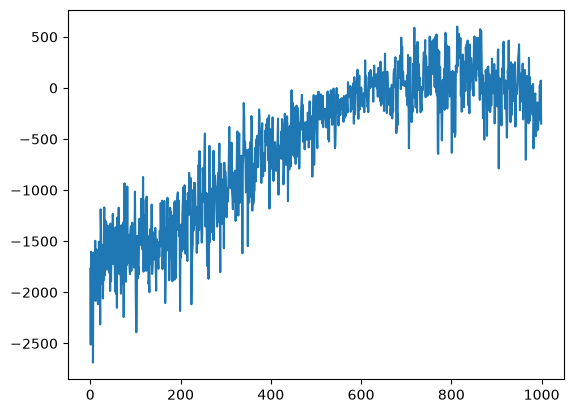

In [16]:
import matplotlib.pyplot as plt

plt.plot(rewards)

In [17]:
def play(model, env, n_rounds, random=True):
    obs, _ = env.reset()
    done = False
    rounds = 0
    while not done:
        if not random:
            logits_actor, _ = model(obs)
            action = Categorical(logits=logits_actor).sample().item()
        else:
            action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        if done:
            done = False
            rounds += 1
            if rounds > n_rounds:
                done = True
            obs, _ = env.reset()
    env.close()

In [18]:
env = gym.make("LunarLander-v3", render_mode='human')
play(model, env, n_rounds=10)